In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
data = pd.read_csv(data_url, sep=';')

print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
print("\nMissing values:")
print(data.isnull().sum())
print("\nBasic statistics:")
data.describe()


Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Basic statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [4]:
X = data.drop('quality', axis=1)
y = data['quality']

# Split into train and holdout sets 70/30
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=17
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Holdout set size: {X_holdout.shape[0]}")

Training set size: 3428
Holdout set size: 1470


### Question 1: MSE on train and holdout sets

In [5]:
# Train Linear Regression without scaling
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr.predict(X_train)
y_holdout_pred_lr = lr.predict(X_holdout)

# Calculate MSE
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_holdout_lr = mean_squared_error(y_holdout, y_holdout_pred_lr)

print(f"MSE on training set: {mse_train_lr:.3f}")
print(f"MSE on holdout set: {mse_holdout_lr:.3f}")

MSE on training set: 0.558
MSE on holdout set: 0.584


### Question 2: Most influential feature

In [6]:
# Get feature coefficients
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_,
    'abs_coefficient': np.abs(lr.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\nFeature importance (by absolute coefficient):")
print(feature_importance_lr)

most_influential = feature_importance_lr.iloc[0]['feature']
print(f"\nANSWER: {most_influential}")


Feature importance (by absolute coefficient):
                 feature  coefficient  abs_coefficient
7                density  -227.551202       227.551202
1       volatile acidity    -1.886874         1.886874
8                     pH     0.995830         0.995830
9              sulphates     0.552495         0.552495
4              chlorides     0.352051         0.352051
0          fixed acidity     0.113731         0.113731
3         residual sugar     0.108183         0.108183
10               alcohol     0.105264         0.105264
5    free sulfur dioxide     0.002439         0.002439
2            citric acid    -0.001485         0.001485
6   total sulfur dioxide     0.000333         0.000333

ANSWER: density


### Questions 3 & 4: Least informative feature and MSE

In [7]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

# Grid search for optimal alpha
alphas = np.logspace(-6, 2, 200)
lasso_cv = GridSearchCV(
    Lasso(random_state=17, max_iter=10000),
    param_grid={'alpha': alphas},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

print(f"\nBest alpha for LASSO: {lasso_cv.best_params_['alpha']:.6f}")

# Get the best model
best_lasso = lasso_cv.best_estimator_

# Predictions
y_train_pred_lasso = best_lasso.predict(X_train_scaled)
y_holdout_pred_lasso = best_lasso.predict(X_holdout_scaled)

# Calculate MSE
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_holdout_lasso = mean_squared_error(y_holdout, y_holdout_pred_lasso)

print(f"MSE on training set: {mse_train_lasso:.3f}")
print(f"MSE on holdout set: {mse_holdout_lasso:.3f}")


Best alpha for LASSO: 0.000283
MSE on training set: 0.558
MSE on holdout set: 0.583


In [8]:
# Feature coefficients
lasso_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_lasso.coef_,
    'abs_coefficient': np.abs(best_lasso.coef_)
}).sort_values('abs_coefficient')

print(lasso_importance)
print("\nFeatures with coefficient = 0 or very close to 0:")
print(lasso_importance[lasso_importance['abs_coefficient'] < 0.01])

least_informative = lasso_importance.iloc[0]['feature']
print(f"\nANSWER: {least_informative}")

                 feature  coefficient  abs_coefficient
2            citric acid    -0.000000         0.000000
4              chlorides     0.006933         0.006933
6   total sulfur dioxide     0.012969         0.012969
5    free sulfur dioxide     0.042698         0.042698
9              sulphates     0.060939         0.060939
0          fixed acidity     0.093295         0.093295
10               alcohol     0.137115         0.137115
8                     pH     0.146549         0.146549
1       volatile acidity    -0.192049         0.192049
3         residual sugar     0.526883         0.526883
7                density    -0.648161         0.648161

Features with coefficient = 0 or very close to 0:
       feature  coefficient  abs_coefficient
2  citric acid    -0.000000         0.000000
4    chlorides     0.006933         0.006933

ANSWER: citric acid


### Question 5: MSE on training, CV, and holdout

In [9]:
# Train Random Forest with default parameters
rf = RandomForestRegressor(random_state=17, n_jobs=-1)
rf.fit(X_train, y_train)

# Training MSE
y_train_pred_rf = rf.predict(X_train)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)

cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
mse_cv_rf = -cv_scores.mean()

# Holdout MSE
y_holdout_pred_rf = rf.predict(X_holdout)
mse_holdout_rf = mean_squared_error(y_holdout, y_holdout_pred_rf)

print(f"MSE on training set: {mse_train_rf:.3f}")
print(f"MSE in cross-validation: {mse_cv_rf:.3f}")
print(f"MSE on holdout set: {mse_holdout_rf:.3f}")

MSE on training set: 0.053
MSE in cross-validation: 0.414
MSE on holdout set: 0.371


### Question 6: MSE for tuned RF

In [10]:
# Grid search for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=17, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_

# CV MSE 
mse_cv_best_rf = -rf_grid.best_score_

# Holdout MSE
y_holdout_pred_best_rf = best_rf.predict(X_holdout)
mse_holdout_best_rf = mean_squared_error(y_holdout, y_holdout_pred_best_rf)

print(f"MSE in cross-validation: {mse_cv_best_rf:.3f}")
print(f"MSE on holdout set: {mse_holdout_best_rf:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
MSE in cross-validation: 0.408
MSE on holdout set: 0.370


### Question 7: Most important feature in Random Forest

In [11]:
# Feature importance from Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance (descending):")
print(rf_feature_importance)

most_important_rf = rf_feature_importance.iloc[0]['feature']
print(f"\nANSWER: {most_important_rf}")


Feature importance (descending):
                 feature  importance
10               alcohol    0.248129
1       volatile acidity    0.125029
5    free sulfur dioxide    0.116265
8                     pH    0.072582
3         residual sugar    0.069261
6   total sulfur dioxide    0.067415
4              chlorides    0.062862
0          fixed acidity    0.062597
7                density    0.059445
2            citric acid    0.058444
9              sulphates    0.057970

ANSWER: alcohol


## visual

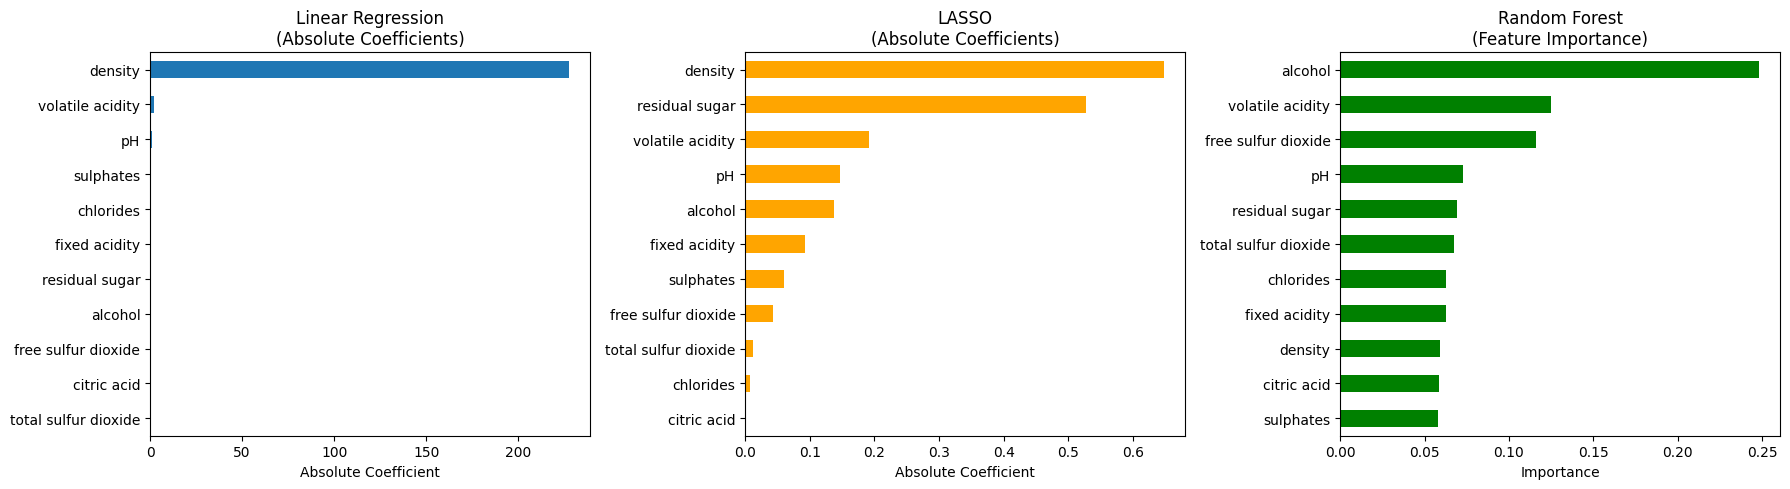

In [12]:
# Compare feature importance across models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear Regression
feature_importance_lr.sort_values('abs_coefficient').plot(
    x='feature', y='abs_coefficient', kind='barh', ax=axes[0], legend=False
)
axes[0].set_title('Linear Regression\n(Absolute Coefficients)')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('')

# LASSO
lasso_importance.sort_values('abs_coefficient').plot(
    x='feature', y='abs_coefficient', kind='barh', ax=axes[1], legend=False, color='orange'
)
axes[1].set_title('LASSO\n(Absolute Coefficients)')
axes[1].set_xlabel('Absolute Coefficient')
axes[1].set_ylabel('')

# Random Forest
rf_feature_importance.sort_values('importance').plot(
    x='feature', y='importance', kind='barh', ax=axes[2], legend=False, color='green'
)
axes[2].set_title('Random Forest\n(Feature Importance)')
axes[2].set_xlabel('Importance')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()